<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week3_Day2_Daily_challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# Mini-Projet Global Power Plant Database
# Bloc 1 : Import & Cleaning
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request, zipfile, os, glob
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Téléchargement et extraction du dataset
url = "https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%206%20-%20Applications%20for%20Data%20Analysis/W6D2%20-%20Advanced%20Numpy/globalpowerplantdatabasev130.zip"
urllib.request.urlretrieve(url, "powerplant.zip")
with zipfile.ZipFile("powerplant.zip") as z:
    z.extractall(".")

# Localisation du CSV principal (le nom peut varier selon la version du dataset)
csv_files = glob.glob("*.csv") + glob.glob("**/*.csv", recursive=True)
main_csv = [f for f in csv_files if 'global_power' in f.lower()][0]
print(f"Fichier chargé : {main_csv}")

# Chargement
df = pd.read_csv(main_csv, low_memory=False)
print(f"\nShape : {df.shape}")
print(f"\nColonnes :\n{df.columns.tolist()}")
df.head()

Fichier chargé : global_power_plant_database.csv

Shape : (34936, 36)

Colonnes :
['country', 'country_long', 'name', 'gppd_idnr', 'capacity_mw', 'latitude', 'longitude', 'primary_fuel', 'other_fuel1', 'other_fuel2', 'other_fuel3', 'commissioning_year', 'owner', 'source', 'url', 'geolocation_source', 'wepp_id', 'year_of_capacity_data', 'generation_gwh_2013', 'generation_gwh_2014', 'generation_gwh_2015', 'generation_gwh_2016', 'generation_gwh_2017', 'generation_gwh_2018', 'generation_gwh_2019', 'generation_data_source', 'estimated_generation_gwh_2013', 'estimated_generation_gwh_2014', 'estimated_generation_gwh_2015', 'estimated_generation_gwh_2016', 'estimated_generation_gwh_2017', 'estimated_generation_note_2013', 'estimated_generation_note_2014', 'estimated_generation_note_2015', 'estimated_generation_note_2016', 'estimated_generation_note_2017']


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.322,65.1190,Hydro,NaN,NaN,...,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.670,65.7950,Solar,NaN,NaN,...,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.623,65.7920,Solar,NaN,NaN,...,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.0,34.556,69.4787,Hydro,NaN,NaN,...,225.06,203.55,146.90,230.18,174.91,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,34.641,69.7170,Hydro,NaN,NaN,...,406.16,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1


In [2]:
# ============================================================
# Bloc 2 : Nettoyage des données
# ============================================================

# Valeurs manquantes par colonne (en %)
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
print("Top 10 colonnes avec le plus de valeurs manquantes (%) :")
print(missing_pct.sort_values(ascending=False).head(10))

# Types de colonnes
print("\nTypes des colonnes principales :")
print(df.dtypes.value_counts())

# Conversion des colonnes numériques avec NumPy (forcer le type)
numeric_cols = ['capacity_mw', 'latitude', 'longitude', 'commissioning_year',
                'year_of_capacity_data', 'generation_gwh_2013', 'generation_gwh_2014',
                'generation_gwh_2015', 'generation_gwh_2016', 'generation_gwh_2017',
                'generation_gwh_2018', 'generation_gwh_2019']

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Suppression des centrales sans capacité (donnée critique)
df_clean = df.dropna(subset=['capacity_mw', 'primary_fuel'])
print(f"\nLignes après nettoyage : {len(df_clean)} (sur {len(df)} initialement)")

# Aperçu
print(f"\nNombre de pays      : {df_clean['country_long'].nunique()}")
print(f"Nombre de fuel types: {df_clean['primary_fuel'].nunique()}")
print(f"Capacité totale     : {df_clean['capacity_mw'].sum():,.0f} MW")

Top 10 colonnes avec le plus de valeurs manquantes (%) :
other_fuel3            99.74
other_fuel2            99.21
other_fuel1            94.44
generation_gwh_2013    81.63
generation_gwh_2014    79.32
generation_gwh_2015    76.52
generation_gwh_2016    73.83
generation_gwh_2017    72.81
generation_gwh_2018    72.42
generation_gwh_2019    72.35
dtype: float64

Types des colonnes principales :
object     19
float64    17
Name: count, dtype: int64

Lignes après nettoyage : 34936 (sur 34936 initialement)

Nombre de pays      : 167
Nombre de fuel types: 15
Capacité totale     : 5,706,975 MW


Statistiques sur capacity_mw :
count    34936.00
mean       163.36
std        489.64
min          1.00
25%          4.90
50%         16.74
75%         75.34
max      22500.00
Name: capacity_mw, dtype: float64

Top 15 pays par nombre de centrales :
country_long
United States of America    9833
China                       4235
United Kingdom              2751
Brazil                      2360
France                      2155
India                       1589
Germany                     1309
Canada                      1159
Spain                        829
Russia                       545
Japan                        522
Australia                    486
Portugal                     469
Czech Republic               462
Italy                        396
Name: count, dtype: int64

Répartition par type de combustible :
primary_fuel
Solar             10665
Hydro              7156
Wind               5344
Gas                3998
Coal               2330
Oil                2320
Biomass            143

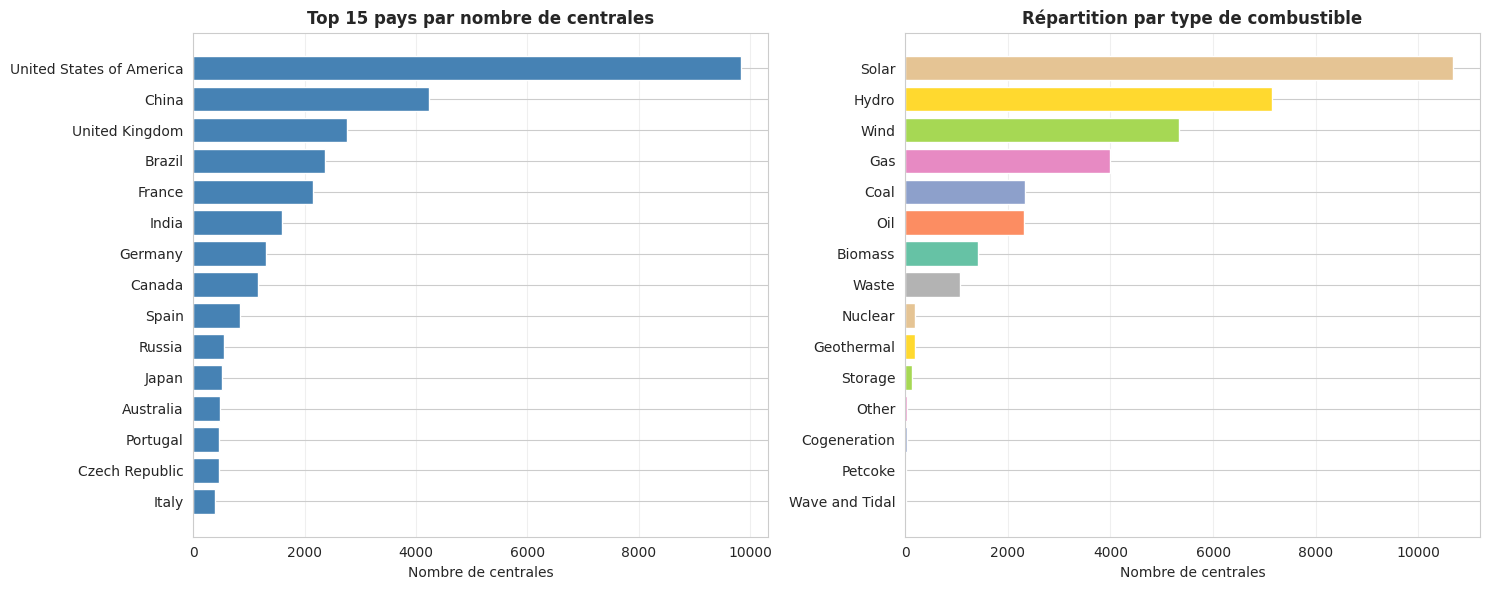

In [3]:
# ============================================================
# Bloc 3 : Exploratory Data Analysis
# ============================================================

# Statistiques globales sur les colonnes numériques
print("Statistiques sur capacity_mw :")
print(df_clean['capacity_mw'].describe().round(2))

# Distribution par pays (Top 15)
top_countries = df_clean['country_long'].value_counts().head(15)
print(f"\nTop 15 pays par nombre de centrales :")
print(top_countries)

# Distribution par fuel type
fuel_counts = df_clean['primary_fuel'].value_counts()
print(f"\nRépartition par type de combustible :")
print(fuel_counts)

# Visualisation : double graphique
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top 15 pays
axes[0].barh(top_countries.index[::-1], top_countries.values[::-1],
             color='steelblue', edgecolor='white')
axes[0].set_xlabel('Nombre de centrales')
axes[0].set_title('Top 15 pays par nombre de centrales', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Fuel types
colors = sns.color_palette("Set2", len(fuel_counts))
axes[1].barh(fuel_counts.index[::-1], fuel_counts.values[::-1],
             color=colors, edgecolor='white')
axes[1].set_xlabel('Nombre de centrales')
axes[1].set_title('Répartition par type de combustible', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()